# scCS Tutorial — Single-Condition Analysis
## Single-cell Commitment Scores with Radial Star Embedding

**scCS v0.7.0** computes RNA velocity-based commitment scores for k-furcation cell fate decisions.

### What scCS does
1. Takes a user-defined **bifurcation cluster** (progenitor) and **k terminal fate clusters**
2. Builds a **radial star embedding** — progenitor at origin, each fate on its own arm
3. Projects **RNA velocity** into this embedding
4. Computes **commitment scores** (unCS, nCS) and per-cell fate affinities
5. Optionally bootstraps **confidence intervals** on all scores
6. Identifies **driver genes** (velocity-based + DEG-based) per fate arm
7. Runs **pathway enrichment** (KEGG, GO BP, Reactome) per fate

### Reference
Kriukov et al. (2025) *Single-cell transcriptome of myeloid cells in response to transplantation of human retinal neurons reveals reversibility of microglial activation*

---
**Notebook outline**

| Section | What you learn |
|---------|---------------|
| 1. Installation | pip install |
| 2. Load & preprocess | scVelo pancreas dataset |
| 3. RNA velocity | scVelo dynamical model |
| 4. Build star embedding | `SingleScorer.build_embedding()` |
| 5. Fix arm coverage | `rebuild_embedding_with_subset_pseudotime()` |
| 6. Fit & score | `fit()`, `score()`, bootstrap CI |
| 7. Visualize | star plot, rose, pairwise heatmap, bar chart |
| 8. Per-cell scores | fate affinity, entropy, NN-smoothed entropy |
| 9. Transfer labels | write scores back to full adata |
| 10. Subset scoring | `score_per_subset()` |
| 11. Driver genes | velocity drivers, DEG drivers |
| 12. Pathway enrichment | KEGG / GO BP per fate |
| 13. Expression trends | `plot_expression_trends()` |


## 1. Installation

In [1]:
%matplotlib inline
# Install from GitHub (recommended)
# !pip install git+https://github.com/mcrewcow/scCS.git

# Or from a local directory:
#!pip install -e /...

import scCS
print(f"scCS version: {scCS.__version__}")

scCS version: 0.7.4


## 2. Load & preprocess data

We use the built-in **pancreas** dataset from scVelo — a well-studied k=4 bifurcation
(Ductal → Alpha, Beta, Delta, Epsilon).  The dataset already contains spliced/unspliced
counts and cluster annotations.


In [2]:
import numpy as np
import pandas as pd
import anndata
import matplotlib.pyplot as plt
import scanpy as sc
import scvelo as scv

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
try:
    from statsmodels.tools.sm_exceptions import ConvergenceWarning
    warnings.filterwarnings("ignore", category=ConvergenceWarning)
except ImportError:
    pass

sc.settings.verbosity = 1
scv.settings.verbosity = 1

adata = scv.datasets.pancreas()
print(adata)
print("\nCluster labels:", adata.obs['clusters'].unique().tolist())

# --- Tutorial display helpers (compact tables instead of per-fate loops) ---
pd.set_option("display.max_rows", 20)
pd.set_option("display.max_columns", 15)
pd.set_option("display.width", 160)


def _stack_drivers(driver_dict, n_per_fate=5, cols=None):
    """Concatenate a {fate: DataFrame} dict into one tidy long-form table.

    Shows the top ``n_per_fate`` rows per fate; adds a ``fate`` column at the
    front. Pass ``cols`` to pick a subset of columns to display.
    """
    out = []
    for fate, df in driver_dict.items():
        if df is None or len(df) == 0:
            continue
        block = df.head(n_per_fate).copy()
        block.insert(0, "fate", fate)
        out.append(block)
    if not out:
        return pd.DataFrame()
    big = pd.concat(out, ignore_index=True)
    if cols is not None:
        keep = ["fate"] + [c for c in cols if c in big.columns]
        big = big[keep]
    return big


def _stack_enrichment(enrichment_dict, n_per_group=3):
    """Flatten enrichment {fate: {direction: df}} into one tidy table."""
    rows = []
    for fate, fate_results in enrichment_dict.items():
        for direction in ("up", "down"):
            df = fate_results.get(direction, None)
            if df is None or df.empty:
                continue
            top = df.head(n_per_group).copy()
            top.insert(0, "direction", direction)
            top.insert(0, "fate", fate)
            rows.append(top)
    if not rows:
        return pd.DataFrame()
    return pd.concat(rows, ignore_index=True)


  0%|          | 0.00/50.0M [00:00<?, ?B/s]

AnnData object with n_obs × n_vars = 3696 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score'
    var: 'highly_variable_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced'
    obsp: 'distances', 'connectivities'

Cluster labels: ['Pre-endocrine', 'Ductal', 'Alpha', 'Ngn3 high EP', 'Delta', 'Beta', 'Ngn3 low EP', 'Epsilon']


In [3]:
# Standard scVelo preprocessing
import inspect as _inspect
_fn_sig = _inspect.signature(scv.pp.filter_and_normalize).parameters
if "n_top_genes" in _fn_sig:
    scv.pp.filter_and_normalize(adata, min_shared_counts=20, n_top_genes=2000)
else:
    # scvelo builds without n_top_genes: do filter_and_normalize then HVG.
    # Use flavor="cell_ranger" not the default "seurat": seurat passes
    # int n_bins to pd.cut on log-dispersions which contain +/-inf for
    # low-mean genes — pandas >= 2.2 rejects this with ValueError.
    # cell_ranger uses explicit bin edges including +/-inf and is
    # robust across pandas/py versions (scCS changelog v0.7.4).
    scv.pp.filter_and_normalize(adata, min_shared_counts=20)
    sc.pp.highly_variable_genes(
        adata, n_top_genes=2000, subset=True, flavor="cell_ranger"
    )
sc.pp.neighbors(adata)
scv.pp.moments(adata, n_pcs=None, n_neighbors=None)

## 3. RNA velocity

We run the **dynamical model** (most accurate) via scVelo.
If your data already has `velocity` and `velocity_graph`, skip this section.


  0%|          | 0/1163 [00:00<?, ?gene/s]

/home/emil/miniforge3/envs/lab-py312/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=3974) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


  0%|          | 0/3696 [00:00<?, ?cells/s]

/home/emil/miniforge3/envs/lab-py312/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=3974) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


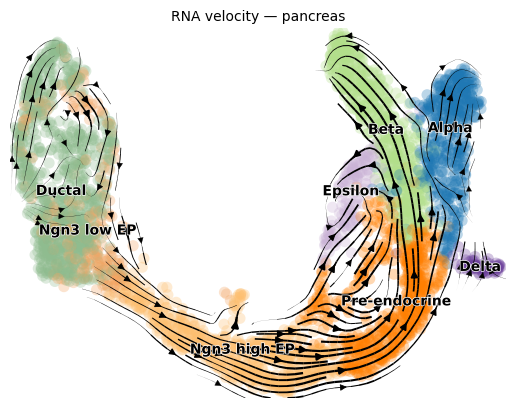

In [4]:
scv.tl.recover_dynamics(adata, n_jobs=32)
scv.tl.velocity(adata, mode="dynamical")
scv.tl.velocity_graph(adata)
scv.tl.velocity_pseudotime(adata)

# Visualise velocity on UMAP
scv.pl.velocity_embedding_stream(adata, basis="umap", color="clusters",
                                  title="RNA velocity — pancreas")

**Alternatively**, you can let scCS run the full velocity pipeline for you:

```python
scorer = scCS.SingleScorer(adata, ...)
scorer.compute_velocity(mode="dynamical", n_top_genes=2000)
```


## 4. Build the radial star embedding

The pancreas dataset has a clear bifurcation from **Ductal** progenitors into
four terminal fates: Alpha, Beta, Delta, Epsilon.

`SingleScorer` requires:
- `root` — the progenitor cluster label
- `branches` — list of terminal fate cluster labels
- `obs_key` — column in `adata.obs` with cluster labels

In [5]:
scorer = scCS.SingleScorer(
    adata,
    root="Pre-endocrine",
    branches=["Alpha", "Beta", "Delta", "Epsilon"],
    obs_key="clusters",
    n_angle_bins=36,          # 10° angular bins (default)
    sector_method="centroid",  # anchor sectors to fate centroids (recommended)
)

# Build the star embedding using scVelo pseudotime
scorer.build_embedding(
    ordering_metric="pseudotime",  # uses adata.obs['velocity_pseudotime']
    arm_scale=10.0,   # maximum radial distance
    jitter=0.3,       # perpendicular noise to avoid overplotting
)

print("Embedding shape:", scorer.adata_sub.obsm["X_sccs"].shape)
print("Cells in embedding:", scorer.adata_sub.n_obs)

[scCS] Building star embedding: root='Pre-endocrine', k=4 fates, metric='pseudotime'
[scCS] Subsetting: 1876 / 3696 cells kept
       (1820 cells from other populations excluded)
       Alpha: 481 cells (fate)
       Beta: 591 cells (fate)
       Delta: 70 cells (fate)
       Epsilon: 142 cells (fate)
       Pre-endocrine: 592 cells (progenitor)

[scCS] Star embedding built → adata_sub.obsm["X_sccs"] shape: (1876, 2)
       Arm angles: {'Alpha': 0.0, 'Beta': 90.0, 'Delta': 180.0, 'Epsilon': 270.0}
[scCS] Star embedding stored in scorer.adata_sub.obsm['X_sccs']. (1876 cells)
Embedding shape: (1876, 2)
Cells in embedding: 1876


## 5. Fix arm coverage with subset-local pseudotime

**Problem:** scVelo pseudotime is computed on the *full* adata.  When we subset to
bifurcation + terminal fate cells, the pseudotime range is compressed — cells cluster
near the origin instead of spanning the full arm length.

**Solution:** `refit_pseudotime()` extracts the velocity_graph
submatrix for the subset cells, recomputes pseudotime locally, scales it to [0, 1],
and rebuilds the embedding.

> **When to use `scale_01=True` vs `False`:**
> - `scale_01=True` (default) — cells span the full arm; best for single-condition analysis
> - `scale_01=False` — preserves absolute pseudotime ordering; use for multi-condition
>   comparisons where cross-condition pseudotime comparability matters


In [6]:
# Recompute pseudotime on the subset subgraph and rebuild the embedding
scorer.refit_pseudotime(scale_01=True)

# Inspect the corrected pseudotime
pt_sub = scorer.adata_sub.obs["velocity_pseudotime"]
print(f"Subset pseudotime range: [{pt_sub.min():.3f}, {pt_sub.max():.3f}]")

[scCS] Recomputing pseudotime on subset (1876 / 3696 cells)...
[scCS] Used scanpy DPT (with diffmap) as pseudotime fallback.
[scCS] Subset pseudotime scaled to [0, 1].
[scCS] Subset pseudotime stored in adata_sub.obs['sccs_pseudotime']. Range: [0.000, 1.000]
[scCS] Rebuilding star embedding with subset-local pseudotime...
[scCS] Subsetting: 1876 / 3696 cells kept
       (1820 cells from other populations excluded)
       Alpha: 481 cells (fate)
       Beta: 591 cells (fate)
       Delta: 70 cells (fate)
       Epsilon: 142 cells (fate)
       Pre-endocrine: 592 cells (progenitor)

[scCS] Star embedding built → adata_sub.obsm["X_sccs"] shape: (1876, 2)
       Arm angles: {'Alpha': 0.0, 'Beta': 90.0, 'Delta': 180.0, 'Epsilon': 270.0}
[scCS] Embedding rebuilt. Call fit() again to update the FateMap and velocity projection.
Subset pseudotime range: [0.495, 1.000]


## 6. Fit and compute commitment scores

`fit()` builds the FateMap (validates clusters, computes fate centroids, projects velocity).
`score()` computes all commitment scores.

### Key outputs in `CommitmentScoreResult`

| Attribute | Description |
|-----------|-------------|
| `pairwise_unCS` | Unnormalized CS matrix (k × k) |
| `pairwise_nCS` | Cell-count-normalized CS matrix (k × k) |
| `commitment_vector` | Fraction of velocity mass per fate |
| `population_entropy` | Population-level commitment entropy |
| `mean_cell_entropy` | Mean per-cell fate entropy |
| `per_fate_entropy` | Per-fate binary entropy |
| `cell_scores` | Per-cell fate affinity matrix (n_cells × k) |
| `bootstrap_ci` | Bootstrap CI dict (if `n_bootstrap > 0`) |


In [7]:
scorer.fit()

[scCS] Root cluster 'Pre-endocrine': 592 cells, centroid=(-0.00, -0.00)
[scCS]   Fate 'Alpha': 481 cells, centroid=(3.51, -0.01)
[scCS]   Fate 'Beta': 591 cells, centroid=(0.03, 4.38)
[scCS]   Fate 'Delta': 70 cells, centroid=(-4.75, -0.05)
[scCS]   Fate 'Epsilon': 142 cells, centroid=(-0.02, -2.55)
[scCS] FateMap built: k=4 fates
[scCS] Projecting velocity via scVelo on full adata → slicing to subset...
[scCS] Velocity projected. Shape: (1876, 2)
FateMap  (root='Pre-endocrine', k=4)
  Cluster key : 'clusters'
  Root cells  : 592
  Root centroid: (-0.005, -0.003)
  Fate 0: 'Alpha'  n_cells=481  centroid=(3.51, -0.01)  arm_angle=0.0°
  Fate 1: 'Beta'  n_cells=591  centroid=(0.03, 4.38)  arm_angle=90.0°
  Fate 2: 'Delta'  n_cells=70  centroid=(-4.75, -0.05)  arm_angle=180.0°
  Fate 3: 'Epsilon'  n_cells=142  centroid=(-0.02, -2.55)  arm_angle=270.0°


SingleScorer(root='Pre-endocrine', branches=['Alpha', 'Beta', 'Delta', 'Epsilon'], k=4, status='fitted')

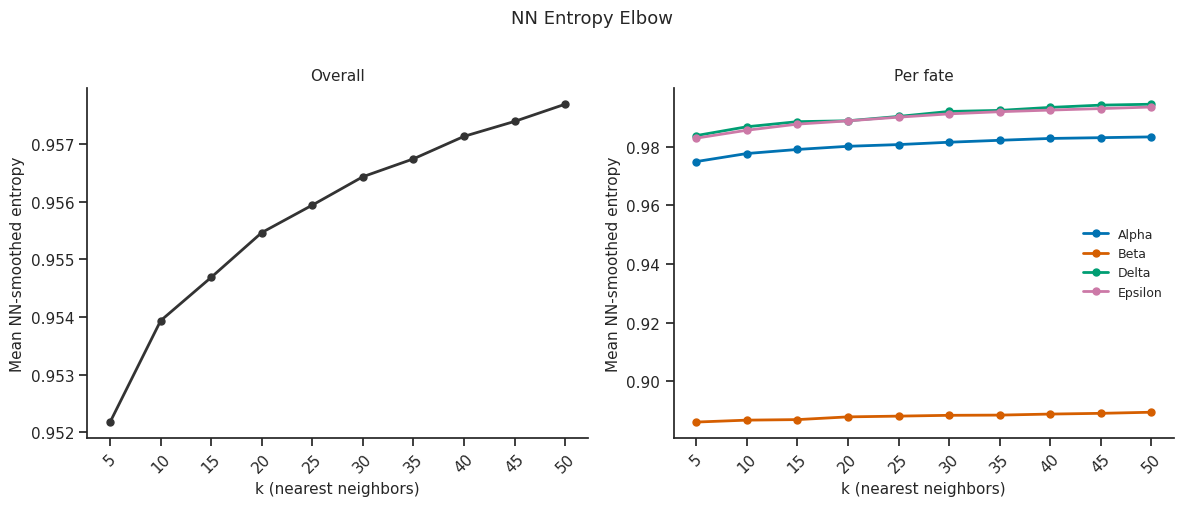

In [8]:
fig = scorer.plot_nn_entropy_elbow(k_nn_range=range(5, 51, 5))
plt.show()

In [9]:
# Score with bootstrap confidence intervals (n_bootstrap=500 recommended)
result = scorer.score(
    cell_level=True,   # compute per-cell fate affinities
    k_nn=15,                   # NN-smoothed entropy (15 nearest neighbours)
    n_bootstrap=500,           # bootstrap CI on nCS
    bootstrap_ci=0.95,         # 95% CI
)

[scCS] Computing bootstrap CI (n=500)...
=== CommitmentScoreResult ===
  Fates (4): Alpha, Beta, Delta, Epsilon
  Dominant fate: Beta

  Entropy metrics:
    Population entropy:           0.7052  [aggregate velocity-mass balance]
    Mean cell entropy:            0.9361  [per-cell average, k-way]
    Per-fate cell entropy:
      Alpha: 0.8246
      Beta: 0.8608
      Delta: 0.7541
      Epsilon: 0.6399
    NN-smoothed entropy (k=15):  mean=0.9547  [per-cell, stored in adata_sub.obs['cs_nn_entropy']]

  Commitment vector (normalized):
    Alpha: 0.2210
    Beta: 0.6449
    Delta: 0.0765
    Epsilon: 0.0576

  Pairwise nCS matrix:
            Alpha      Beta     Delta   Epsilon
Alpha    1.000000  0.421157  0.420532  1.133082
Beta     2.374413  1.000000  0.998516  2.690405
Delta    2.377942  1.001486  1.000000  2.694404
Epsilon  0.882548  0.371691  0.371140  1.000000

  Bootstrap 95% CI on nCS (n=500):
    CI low:
         Alpha   Beta  Delta  Epsilon
Alpha    1.000  0.369  0.352    0.922

In [10]:
# Summary table
print(result.summary())

=== CommitmentScoreResult ===
  Fates (4): Alpha, Beta, Delta, Epsilon
  Dominant fate: Beta

  Entropy metrics:
    Population entropy:           0.7052  [aggregate velocity-mass balance]
    Mean cell entropy:            0.9361  [per-cell average, k-way]
    Per-fate cell entropy:
      Alpha: 0.8246
      Beta: 0.8608
      Delta: 0.7541
      Epsilon: 0.6399
    NN-smoothed entropy (k=15):  mean=0.9547  [per-cell, stored in adata_sub.obs['cs_nn_entropy']]

  Commitment vector (normalized):
    Alpha: 0.2210
    Beta: 0.6449
    Delta: 0.0765
    Epsilon: 0.0576

  Pairwise nCS matrix:
            Alpha      Beta     Delta   Epsilon
Alpha    1.000000  0.421157  0.420532  1.133082
Beta     2.374413  1.000000  0.998516  2.690405
Delta    2.377942  1.001486  1.000000  2.694404
Epsilon  0.882548  0.371691  0.371140  1.000000

  Bootstrap 95% CI on nCS (n=500):
    CI low:
         Alpha   Beta  Delta  Epsilon
Alpha    1.000  0.369  0.352    0.922
Beta     2.119  1.000  0.851    2.270
De

In [11]:
# Access individual scores
print("Pairwise nCS matrix:")
print(pd.DataFrame(
    result.pairwise_nCS,
    index=result.fate_names,
    columns=result.fate_names
).round(3))

print("\nCommitment vector (fraction of velocity mass per fate):")
for fate, cv in zip(result.fate_names, result.commitment_vector):
    print(f"  {fate}: {cv:.3f}")

print(f"\nPopulation entropy: {result.population_entropy:.3f}")
print(f"Mean per-cell entropy: {result.mean_cell_entropy:.3f}")

Pairwise nCS matrix:
         Alpha   Beta  Delta  Epsilon
Alpha    1.000  0.421  0.421    1.133
Beta     2.374  1.000  0.999    2.690
Delta    2.378  1.001  1.000    2.694
Epsilon  0.883  0.372  0.371    1.000

Commitment vector (fraction of velocity mass per fate):
  Alpha: 0.221
  Beta: 0.645
  Delta: 0.076
  Epsilon: 0.058

Population entropy: 0.705
Mean per-cell entropy: 0.936


In [12]:
# Bootstrap CI (if n_bootstrap > 0)
if result.bootstrap_ci is not None:
    ci = result.bootstrap_ci
    print(f"Bootstrap CI ({int(ci['ci_level']*100)}%, n={ci['n_bootstrap']}):")
    print("  nCS CI low:")
    print(pd.DataFrame(ci['ci_low'], index=result.fate_names, columns=result.fate_names).round(3))
    print("\n  nCS CI high:")
    print(pd.DataFrame(ci['ci_high'], index=result.fate_names, columns=result.fate_names).round(3))

Bootstrap CI (95%, n=500):
  nCS CI low:
         Alpha   Beta  Delta  Epsilon
Alpha    1.000  0.369  0.352    0.922
Beta     2.119  1.000  0.851    2.270
Delta    1.989  0.855  1.000    2.103
Epsilon  0.723  0.303  0.290    1.000

  nCS CI high:
         Alpha   Beta  Delta  Epsilon
Alpha    1.000  0.472  0.503    1.383
Beta     2.712  1.000  1.170    3.297
Delta    2.838  1.175  1.000    3.449
Epsilon  1.084  0.440  0.476    1.000


## 7. Visualizations

scCS provides several built-in plots.  All are accessible as methods on the scorer
or as standalone functions in `scCS.plot`.


### 7.1 Radial star embedding

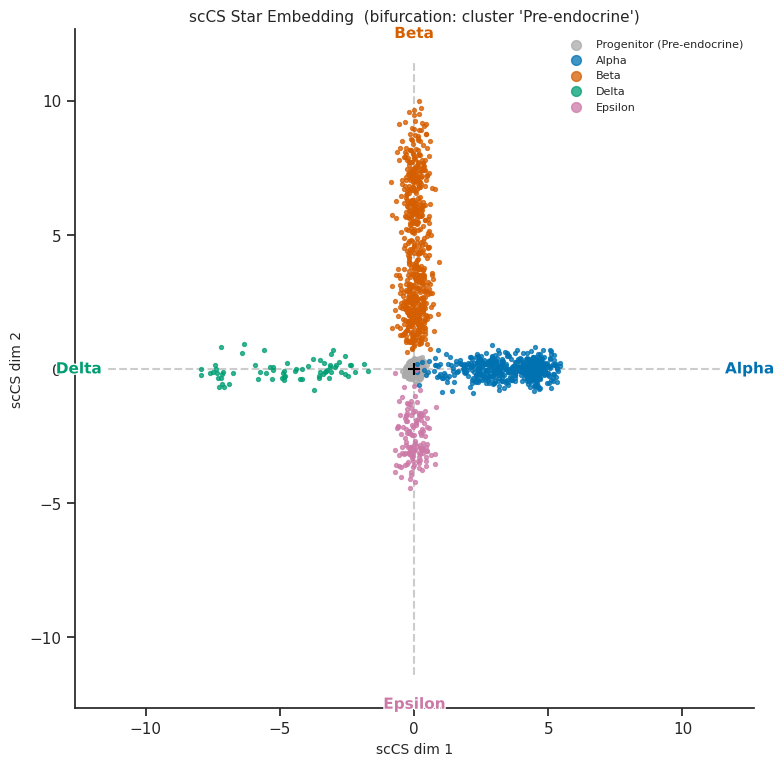

In [13]:
# Primary visualization: cells in the star embedding, coloured by fate
fig = scorer.plot_star(result, figsize=(8, 8))
plt.tight_layout()
plt.show()

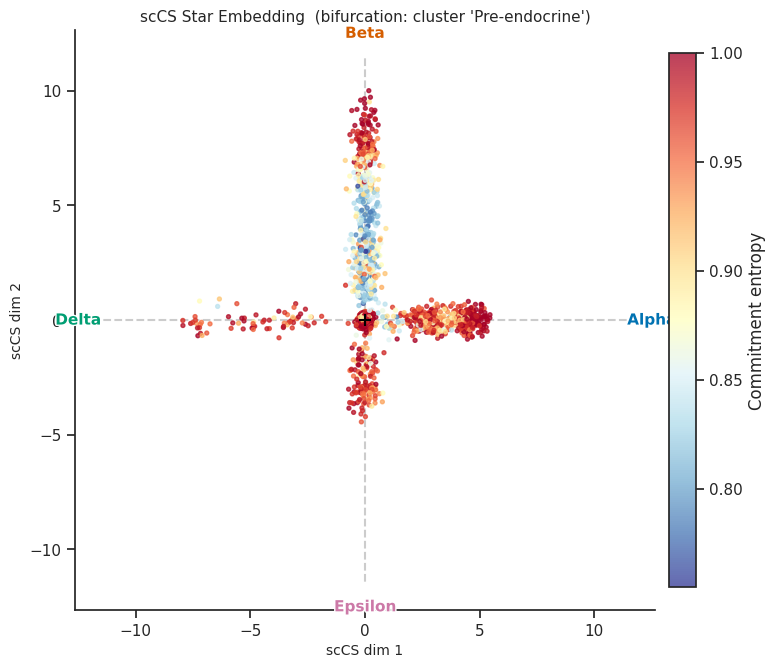

In [14]:
# Colour by per-cell entropy instead of fate
fig = scorer.plot_star(result, color_by="entropy", figsize=(8, 8))
plt.tight_layout()
plt.show()

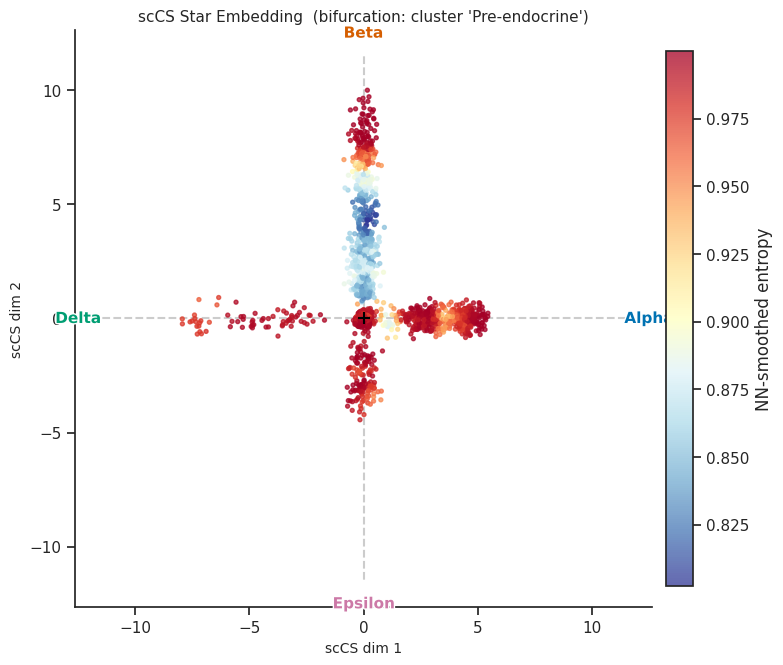

In [15]:
# Colour by NN-smoothed entropy (requires k_nn in score())
fig = scorer.plot_star(result, color_by="nn_entropy", figsize=(8, 8))
plt.tight_layout()
plt.show()

### 7.2 Rose / polar plot

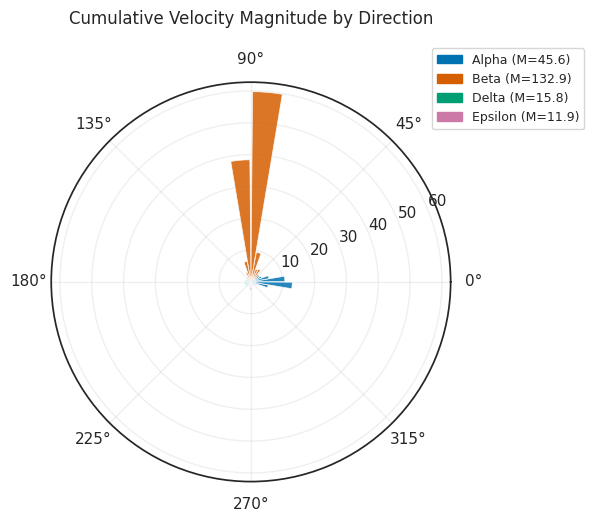

In [16]:
# Rose plot: cumulative velocity magnitude per angular bin
fig = scorer.plot_rose(result, figsize=(6, 6))
plt.tight_layout()
plt.show()

### 7.3 Pairwise nCS heatmap

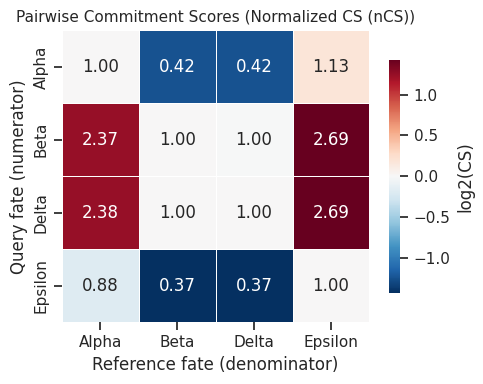

In [17]:
# Heatmap of pairwise normalized commitment scores
fig = scorer.plot_pairwise_cs(result, figsize=(5, 4))
plt.tight_layout()
plt.show()

### 7.4 Commitment bar chart

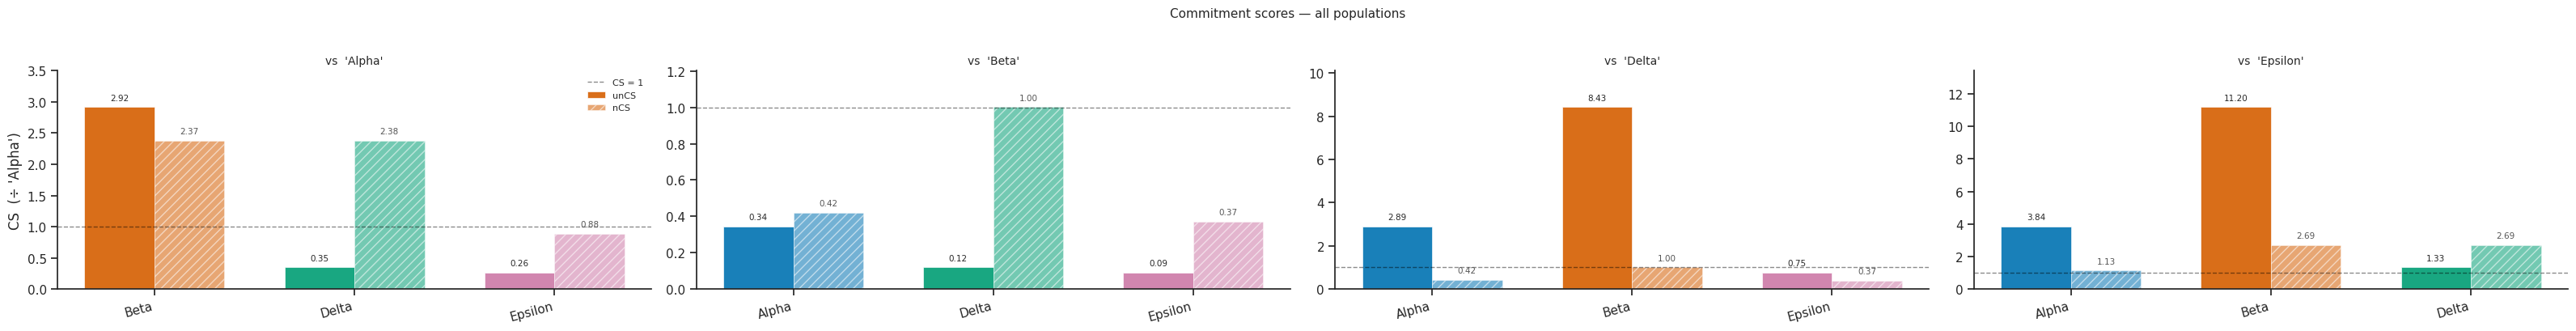

In [18]:
# Bar chart: unCS vs nCS per fate pair
fig = scorer.plot_commitment_bar(result, figsize=(8, 4))
plt.tight_layout()
plt.show()

### 7.5 Per-cell fate affinity heatmap

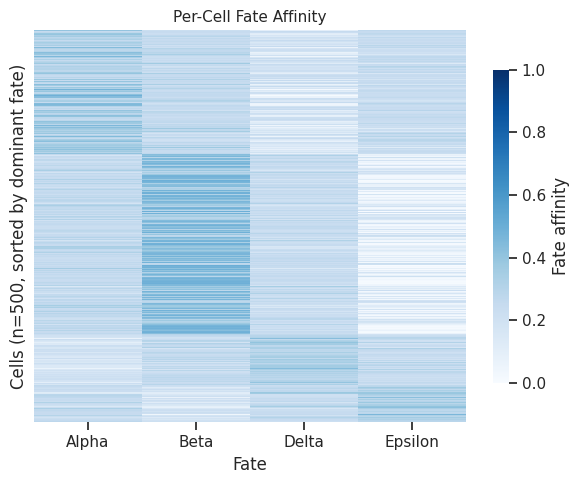

In [19]:
# Heatmap of per-cell fate affinities (rows = cells, cols = fates)
fig = scorer.plot_commitment_heatmap(result, figsize=(6, 5), max_cells=500)
plt.tight_layout()
plt.show()

### 7.6 NN entropy elbow plot

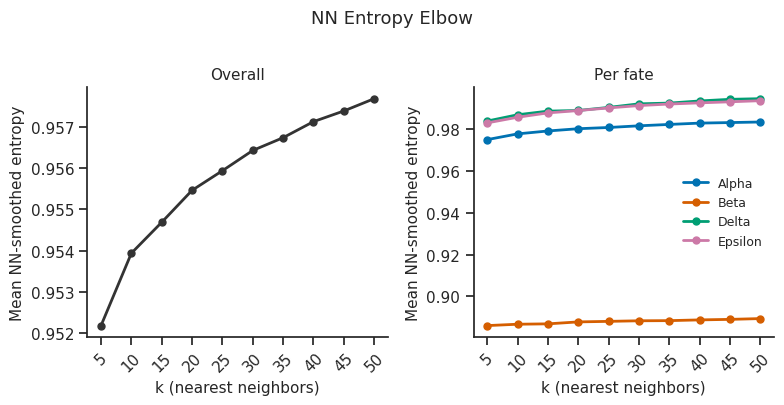

In [20]:
# Elbow plot to choose k_nn for NN-smoothed entropy
# Sweeps k_nn values and plots mean NN entropy
fig = scorer.plot_nn_entropy_elbow(k_nn_range=range(5, 51, 5), figsize=(8, 4))
plt.tight_layout()
plt.show()

## 8. Per-cell fate affinity scores

After `score(cell_level=True)`, per-cell scores are stored in
`scorer.adata_sub.obs`:

| Column | Description |
|--------|-------------|
| `cs_{fate_name}` | Per-cell affinity for each fate (sums to 1 per cell) |
| `cs_dominant_fate` | Fate with highest affinity |
| `cs_entropy` | Per-cell commitment entropy (0 = fully committed, 1 = uniform) |
| `cs_nn_entropy` | NN-smoothed entropy (if `k_nn` was set) |
| `velocity_pseudotime_sub` | Subset-local pseudotime |


In [21]:
# Inspect per-cell scores
obs_cols = [c for c in scorer.adata_sub.obs.columns if c.startswith("cs_")]
print("Per-cell score columns:", obs_cols)
scorer.adata_sub.obs[obs_cols].head(10)

Per-cell score columns: ['cs_Alpha', 'cs_Beta', 'cs_Delta', 'cs_Epsilon', 'cs_dominant_fate', 'cs_entropy', 'cs_nn_entropy']


,cs_Alpha,cs_Beta,cs_Delta,cs_Epsilon,cs_dominant_fate,cs_entropy,cs_nn_entropy
index,,,,,,,
AAACCTGAGAGGGATA,0.345656,0.252071,0.154299,0.247973,Alpha,0.972886,0.992053
AAACCTGAGGCAATTA,0.247055,0.296687,0.252668,0.203590,Beta,0.993692,0.992740
AAACCTGTCCCTCTTT,0.324502,0.244887,0.175503,0.255107,Alpha,0.983665,0.958981
AAACGGGAGTAGCGGT,0.361040,0.324278,0.138481,0.176201,Alpha,0.946906,0.977282
AAACGGGCAAAGAATC,0.274640,0.476842,0.224002,0.024516,Beta,0.818077,0.875318
AAACGGGGTACAGTTC,0.251495,0.463168,0.247236,0.038101,Beta,0.846585,0.884746
AAACGGGGTCGGGTCT,0.268075,0.221469,0.232088,0.278367,Epsilon,0.996724,0.998418
AAACGGGTCCGCGCAA,0.328827,0.381496,0.170364,0.119313,Beta,0.929480,0.988123
AAACGGGTCGCATGGC,0.272847,0.479499,0.225780,0.021874,Beta,0.812556,0.817800


In [22]:
# Distribution of dominant fate assignments
print(scorer.adata_sub.obs["cs_dominant_fate"].value_counts())

cs_dominant_fate
Beta       836
Alpha      604
Delta      246
Epsilon    190
Name: count, dtype: int64


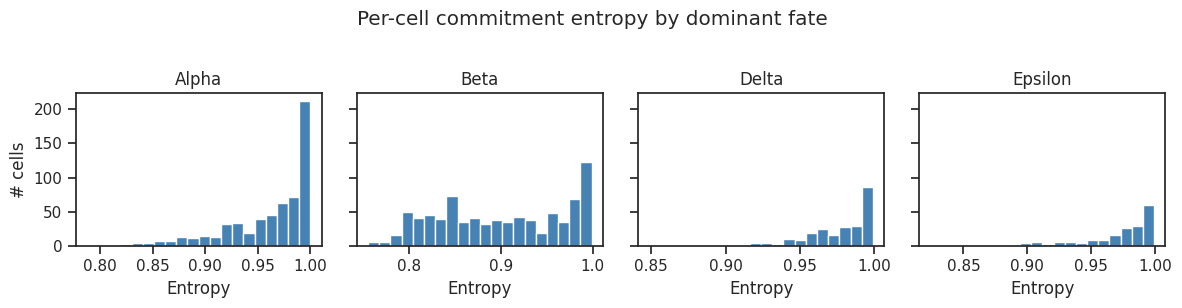

In [23]:
# Entropy distribution per fate
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(result.fate_names), figsize=(12, 3), sharey=True)
for ax, fate in zip(axes, result.fate_names):
    mask = scorer.adata_sub.obs["cs_dominant_fate"] == fate
    ax.hist(scorer.adata_sub.obs.loc[mask, "cs_entropy"], bins=20, color="steelblue", edgecolor="white")
    ax.set_title(fate)
    ax.set_xlabel("Entropy")
axes[0].set_ylabel("# cells")
plt.suptitle("Per-cell commitment entropy by dominant fate", y=1.02)
plt.tight_layout()
plt.show()

## 9. Transfer labels to full adata

`transfer_labels()` writes per-cell scores from `adata_sub` back to the full adata,
so you can use them in UMAP plots, downstream analyses, or integration with other tools.

Cells not in the embedding subset receive `NaN` (numeric) or `'unassigned'` (categorical).


In [24]:
scorer.transfer_labels(adata, result, prefix="cs_")

# Columns added to adata.obs
cs_cols = [c for c in adata.obs.columns if c.startswith("cs_")]
print("Columns added to adata.obs:", cs_cols)
adata.obs[cs_cols].head()

[scCS] Labels transferred to adata.obs for 1876 / 3696 cells. Columns: ['cs_Alpha', 'cs_Beta', 'cs_Delta', 'cs_Epsilon', 'cs_dominant_fate', 'cs_entropy']
Columns added to adata.obs: ['cs_Alpha', 'cs_Beta', 'cs_Delta', 'cs_Epsilon', 'cs_dominant_fate', 'cs_entropy', 'cs_nn_entropy']


,cs_Alpha,cs_Beta,cs_Delta,cs_Epsilon,cs_dominant_fate,cs_entropy,cs_nn_entropy
index,,,,,,,
AAACCTGAGAGGGATA,0.345656,0.252071,0.154299,0.247973,Alpha,0.972886,0.992053
AAACCTGAGCCTTGAT,NaN,NaN,NaN,NaN,unassigned,NaN,NaN
AAACCTGAGGCAATTA,0.247055,0.296687,0.252668,0.203590,Beta,0.993692,0.992740
AAACCTGCATCATCCC,NaN,NaN,NaN,NaN,unassigned,NaN,NaN
AAACCTGGTAAGTGGC,NaN,NaN,NaN,NaN,unassigned,NaN,NaN


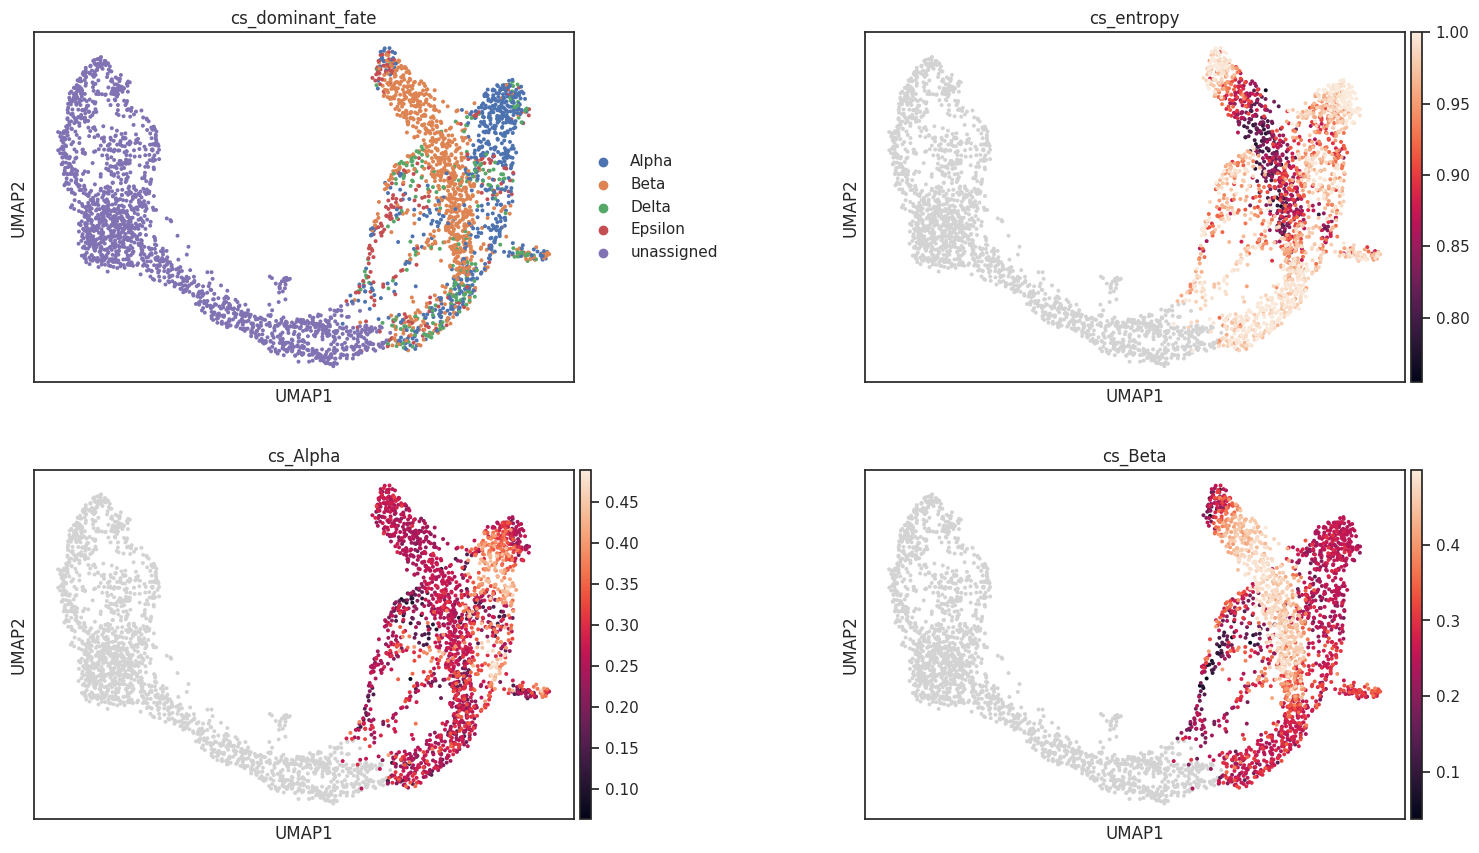

In [25]:
# Visualize on UMAP
sc.pl.umap(adata, color=["cs_dominant_fate", "cs_entropy", "cs_Alpha", "cs_Beta"],
           ncols=2, wspace=0.4)

## 10. Subset scoring

`score_per_subset()` computes commitment scores separately for each value of a
metadata column in `adata_sub.obs`.  Useful for comparing commitment across
time points, batches, or any categorical variable.

> **Note:** The mask is applied to `adata_sub` (the embedding subset), not the full adata.

> **Note on `inf` in pairwise nCS:** When a subset contains only progenitor cells (e.g., 'Pre-endocrine') with no cells from any fate arm, `pairwise_nCS` will be `inf` for all off-diagonal entries. This is mathematically correct — nCS is undefined when a fate arm has 0 cells. A `UserWarning` is emitted automatically. Progenitor-only subsets are still useful for inspecting the commitment vector and population entropy.


In [26]:
# Score separately for each cluster within the embedding
# (Here we use 'clusters' as a demo; in practice use a condition/batch column)
subset_results = scorer.score_per_subset(
    split_by="clusters",
    cell_level=False,
    n_bootstrap=0,
    verbose=False,
)

# Tidy summary: one row per subset with all off-diagonal nCS values + status
def _subset_summary(subset_results):
    rows = []
    for subset_name, res in subset_results.items():
        n = len(res.fate_names)
        ncs = res.pairwise_nCS
        row = {"subset": subset_name, "n_cells_in_fate": int(res.n_cells_per_fate.sum())}
        for i in range(n):
            for j in range(i + 1, n):
                col = f"nCS[{res.fate_names[i]} vs {res.fate_names[j]}]"
                row[col] = float(ncs[i, j])
        # Status flag: any inf?
        off_diag = [ncs[i, j] for i in range(n) for j in range(n) if i != j]
        if all(np.isinf(v) for v in off_diag):
            row["status"] = "progenitor-only (inf)"
        elif any(np.isinf(v) for v in off_diag):
            row["status"] = "partial (some inf)"
        else:
            row["status"] = "ok"
        rows.append(row)
    return pd.DataFrame(rows)

summary_df = _subset_summary(subset_results)
summary_df


,subset,n_cells_in_fate,nCS[Alpha vs Beta],nCS[Alpha vs Delta],nCS[Alpha vs Epsilon],nCS[Beta vs Delta],nCS[Beta vs Epsilon],nCS[Delta vs Epsilon],status
0,Pre-endocrine,0,inf,inf,inf,inf,inf,inf,progenitor-only (inf)
1,Alpha,481,0.0,0.0,0.0,inf,inf,inf,partial (some inf)
2,Delta,70,inf,inf,inf,inf,inf,0.0,partial (some inf)
3,Beta,591,inf,inf,inf,0.0,0.0,inf,partial (some inf)
4,Epsilon,142,inf,inf,inf,inf,inf,inf,partial (some inf)


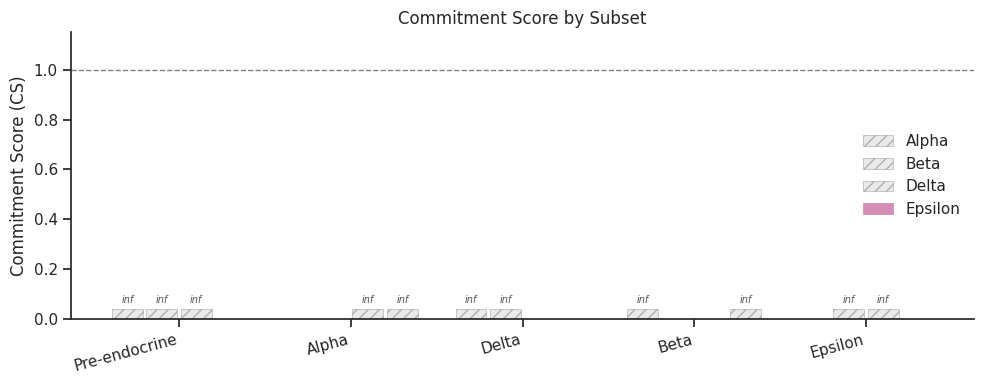

In [27]:
# Visualize subset comparison
fig = scorer.plot_subset_comparison(subset_results, figsize=(10, 4))
plt.tight_layout()
plt.show()

## 11. Driver genes

scCS provides three complementary approaches to identify fate-driving genes:

1. **Velocity drivers** (`get_velocity_drivers`) — genes with highest mean RNA velocity in each fate arm
   (high positive velocity = gene is being upregulated along that fate)
2. **DEG drivers** — differentially expressed genes between each fate arm and
   the bifurcation cluster (Wilcoxon rank-sum test)
3. **Velocity-fate correlation drivers** (`get_velocity_fate_drivers`) — Spearman correlation between each gene's velocity and per-cell fate affinity. Stronger signal than mean velocity because it filters out genes that are fast everywhere.


In [28]:
# Velocity-based driver genes (top 20 per fate)
vel_drivers = scorer.get_velocity_drivers(n_top_genes=20)

# Compact long-form table: top 5 per fate, one DataFrame
print("Top velocity drivers (top 5 per fate):")
_stack_drivers(vel_drivers, n_per_fate=5, cols=["gene", "mean_velocity", "rank"])



── Velocity drivers: Alpha (top 20, sorted by delta_velocity) ──
 rank     gene  delta_velocity  mean_velocity
    1      Clu        1.488299       1.532060
    2     Cpa2        1.242302       0.851096
    3   Cryba2        1.057625       1.217162
    4     Ghrl        0.986426       0.384223
    5    Meis2        0.821635       0.665699
    6     Pax6        0.726139       0.883325
    7   Npepl1        0.725493       0.182687
    8   Tm4sf4        0.668253       0.466062
    9     Vasp        0.611339       0.097546
   10     Pax4        0.603224       0.034867
   11   Btbd17        0.577881       0.930656
   12     Krt7        0.547158      -0.280244
   13    Cd200        0.535196       0.330072
   14    Celf3        0.534336       0.370460
   15     Tox3        0.497146       0.251629
   16     Pdx1        0.496890       0.392475
   17   Ppp3ca        0.487356       0.200745
   18      Hn1        0.468364       0.031799
   19 BC023829        0.455840       0.336861
   20     Cpt2

,fate,gene,mean_velocity,rank
0,Alpha,Clu,1.532060,1
1,Alpha,Cpa2,0.851096,2
2,Alpha,Cryba2,1.217162,3
3,Alpha,Ghrl,0.384223,4
4,Alpha,Meis2,0.665699,5
5,Beta,Ins2,3.689225,1
6,Beta,Nnat,4.051527,2
7,Beta,Isl1,1.070217,3
8,Beta,Clu,1.648854,4
9,Beta,1700086L19Rik,0.453118,5


In [29]:
# DEG-based driver genes (top 20 per fate, vs the bifurcation cluster)
deg_drivers = scorer.get_deg_drivers(
    n_top_genes=20,
    pval_threshold=0.05,
    logfc_threshold=0.25,
)

print("Top DEG drivers (top 5 per fate):")
_stack_drivers(
    deg_drivers, n_per_fate=5,
    cols=["gene", "logfoldchange", "pval_adj", "pct_fate", "pct_progenitor"],
)



── DEG drivers: Alpha vs progenitor ──
   Significant: 761  (up: 376, down: 385)
   gene  logfoldchange      pval_adj  pct_fate  pct_progenitor
    Pyy     209.768677  1.181761e-93  0.968815             NaN
    Gcg     209.614731  9.196179e-64  0.656965             NaN
   Iapp      99.370232  4.065913e-99  0.854470             NaN
    Ttr      67.718864 2.617159e-103  1.000000             NaN
   Gnas      34.805965  2.937512e-52  1.000000             NaN
   Rbp4      33.815922  7.031753e-50  0.962578             NaN
  Hpgds      26.723766  3.763407e-02  0.087318             NaN
    Tnr      26.722797  2.795890e-02  0.091476             NaN
 Tmem27      17.364475 1.123328e-141  0.981289             NaN
Slc38a5      15.393972  4.940813e-60  0.920998             NaN
 Pcsk1n      12.127839  4.762578e-59  0.997921             NaN
   Gast       9.842274  1.419605e-32  0.538462             NaN
    Cpe       7.672148  1.079724e-40  1.000000             NaN
  Pcsk2       7.646369  6.491126e-63

,fate,gene,logfoldchange,pval_adj,pct_fate,pct_progenitor
0,Alpha,Pyy,209.768677,1.181761e-93,0.968815,NaN
1,Alpha,Gcg,209.614731,9.196179e-64,0.656965,NaN
2,Alpha,Iapp,99.370232,4.065913e-99,0.854470,NaN
3,Alpha,Ttr,67.718864,2.617159e-103,1.000000,NaN
4,Alpha,Gnas,34.805965,2.937512e-52,1.000000,NaN
5,Beta,Iapp,185.345184,6.106240e-152,0.944162,NaN
6,Beta,Pyy,139.123322,1.052978e-85,0.962775,NaN
7,Beta,Ins1,99.108521,3.512617e-47,0.582064,NaN
8,Beta,Ins2,47.560135,3.515790e-67,0.610829,NaN
9,Beta,Nnat,42.420864,2.029962e-103,0.825719,NaN


### 11.3 Velocity-fate correlation drivers

`get_velocity_fate_drivers()` computes the **Spearman correlation** between each gene's
velocity and the per-cell fate affinity score for each fate arm. Genes with high positive
correlation are being upregulated specifically as cells commit to that fate — a stronger
signal than mean velocity alone, because it filters out genes that are fast everywhere.

Requires `score(cell_level=True)` to have been called first (needs `result.cell_scores`).


In [30]:
# Velocity-fate correlation drivers
# Correlates each gene's velocity with per-cell fate affinity scores
# (requires cell_level=True in score())
try:
    vf_drivers = scorer.get_velocity_fate_drivers(
        result,
        n_top_genes=20,
        pval_threshold=0.05,
    )
    print("Top velocity-fate drivers (top 5 per fate):")
    display(_stack_drivers(
        vf_drivers, n_per_fate=5,
        cols=["gene", "spearman_r", "pval_adj", "mean_velocity", "delta_velocity"],
    ))
except ValueError as e:
    print(f"Skipped: {e}")
    print("Tip: call scorer.score(cell_level=True) first.")



── Velocity-fate drivers: Alpha (top 20, sorted by Spearman r) ──
   Significant (FDR < 0.05): 683 / 2000
 rank          gene  spearman_r     pval_adj  mean_velocity
    1        Adam23    0.332275 2.726568e-46       0.035280
    2           Klb    0.309560 6.025260e-40       0.045717
    3       Tmem206    0.265787 4.237692e-29       0.099139
    4        Notch2    0.257026 2.741812e-27       0.073804
    5        Sorcs2    0.235934 5.877863e-23       0.037468
    6       Rasgrf2    0.235511 6.661376e-23       0.025164
    7         Epha4    0.235026 7.813431e-23       0.052760
    8        Megf11    0.228079 1.824037e-21       0.007886
    9          Sgce    0.224234 9.184396e-21       0.052389
   10         Kif2c    0.223713 1.097454e-20       0.083291
   11         Sel1l    0.223152 1.274883e-20       0.055911
   12          Bst2    0.222681 1.434448e-20       0.190410
   13          Ctsb    0.219757 4.981190e-20      -0.068126
   14        Gabrb3    0.217725 1.071893e-19       0.

,fate,gene,spearman_r,pval_adj,mean_velocity,delta_velocity
0,Alpha,Adam23,0.332275,2.726568e-46,0.035280,0.026601
1,Alpha,Klb,0.309560,6.025260e-40,0.045717,0.037019
2,Alpha,Tmem206,0.265787,4.237692e-29,0.099139,0.149552
3,Alpha,Notch2,0.257026,2.741812e-27,0.073804,0.069658
4,Alpha,Sorcs2,0.235934,5.877863e-23,0.037468,0.026698
5,Beta,Gng12,0.687204,4.410440e-259,0.364720,0.065286
6,Beta,Nnat,0.675808,1.430221e-247,4.051527,3.631306
7,Beta,Sdk2,0.571355,3.286960e-160,0.011898,0.011638
8,Beta,Dact2,0.559535,2.499373e-152,0.045325,0.018165
9,Beta,Ap1s2,0.549641,5.731258e-146,0.087439,0.024644


## 12. Pathway enrichment

`get_enrichment()` runs over-representation analysis (ORA) on the DEG driver genes
for each fate using **gseapy** (KEGG, GO Biological Process, Reactome).

Requires an internet connection and a valid organism code.



  Pathway enrichment: Alpha
  Gene sets: ['KEGG_2019_Mouse', 'GO_Biological_Process_2021', 'Reactome_2022']
  Up-regulated genes  : 376
  Down-regulated genes: 385

  [up] Significant terms: 121
       Gene_set                                                       Term Overlap  Adjusted P-value
KEGG_2019_Mouse                Protein processing in endoplasmic reticulum  17/163          0.000003
KEGG_2019_Mouse                                  Thyroid hormone synthesis   10/73          0.000127
KEGG_2019_Mouse                                                   Lysosome  12/124          0.000313
KEGG_2019_Mouse                                     Gastric acid secretion    9/74          0.000600
  Reactome_2022   Response To Elevated Platelet Cytosolic Ca2+ R-HSA-76005  13/130          0.000783
KEGG_2019_Mouse                                      Circadian entrainment   10/99          0.000825
  Reactome_2022                        Platelet Degranulation R-HSA-114608  12/125          0.000

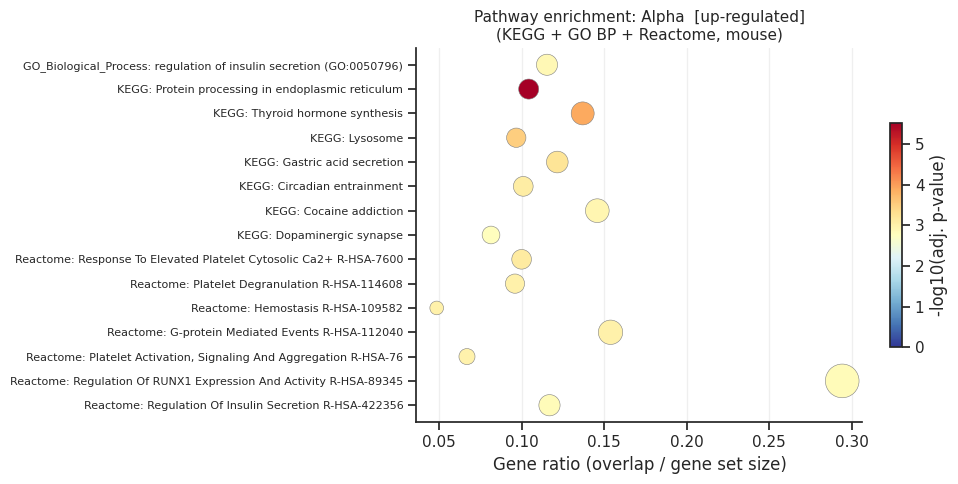

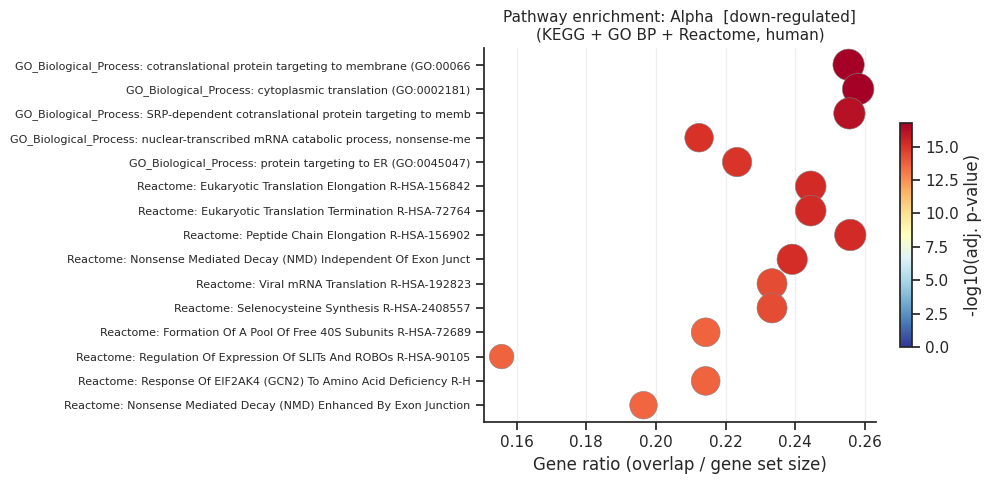


  Pathway enrichment: Beta
  Gene sets: ['KEGG_2019_Mouse', 'GO_Biological_Process_2021', 'Reactome_2022']
  Up-regulated genes  : 422
  Down-regulated genes: 408

  [up] Significant terms: 121
                  Gene_set                                                     Term Overlap  Adjusted P-value
           KEGG_2019_Mouse              Protein processing in endoplasmic reticulum  23/163      1.407868e-10
GO_Biological_Process_2021     IRE1-mediated unfolded protein response (GO:0036498)   12/53      1.863342e-06
           KEGG_2019_Mouse                                        Insulin secretion   13/86      3.415612e-06
             Reactome_2022 Amino Acid Transport Across Plasma Membrane R-HSA-352230    9/33      1.321921e-05
             Reactome_2022              IRE1alpha Activates Chaperones R-HSA-381070   10/48      1.321921e-05
             Reactome_2022             Unfolded Protein Response (UPR) R-HSA-381119   13/89      1.321921e-05
             Reactome_2022         

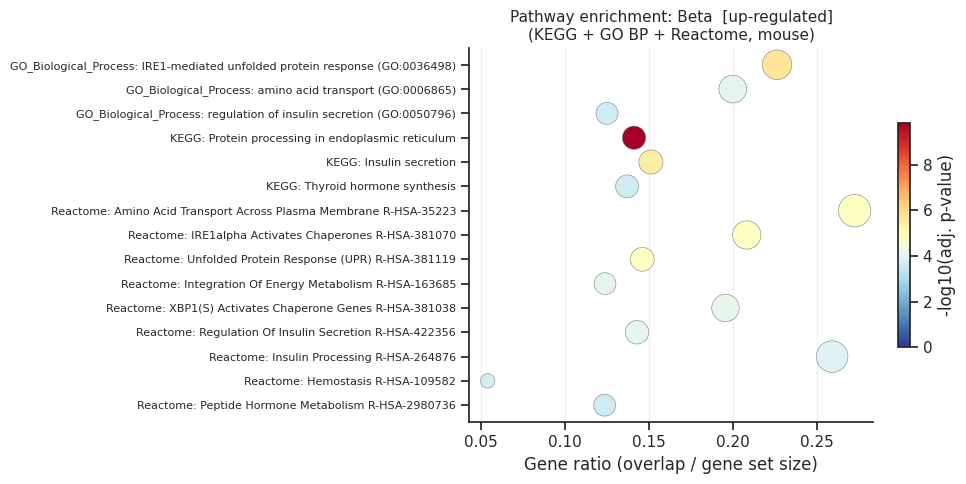

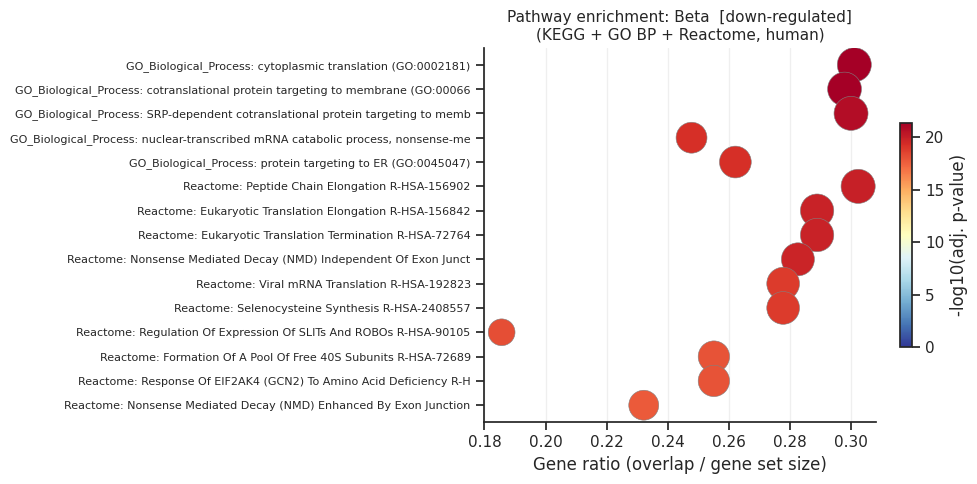


  Pathway enrichment: Delta
  Gene sets: ['KEGG_2019_Mouse', 'GO_Biological_Process_2021', 'Reactome_2022']
  Up-regulated genes  : 156
  Down-regulated genes: 230

  [up] Significant terms: 41
                  Gene_set                                                                        Term Overlap  Adjusted P-value
           KEGG_2019_Mouse                                 Protein processing in endoplasmic reticulum  14/163      6.690234e-09
           KEGG_2019_Mouse                                                   Thyroid hormone synthesis    7/73      1.429359e-04
             Reactome_2022                                         Metabolism Of Proteins R-HSA-392499 35/1890      3.776032e-04
             Reactome_2022                                 IRE1alpha Activates Chaperones R-HSA-381070    5/48      3.289099e-03
             Reactome_2022                Incretin Synthesis, Secretion, And Inactivation R-HSA-400508    4/24      3.289099e-03
             Reactome_2022   SR

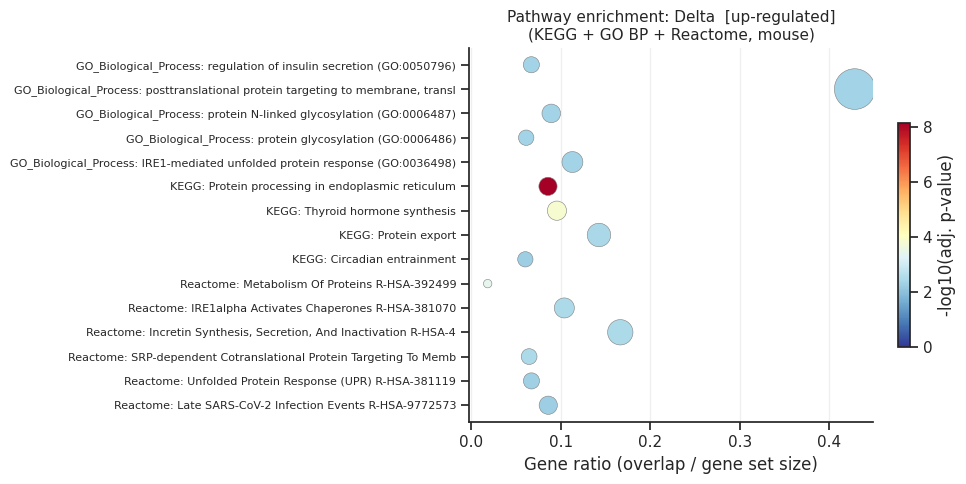


  Pathway enrichment: Epsilon
  Gene sets: ['KEGG_2019_Mouse', 'GO_Biological_Process_2021', 'Reactome_2022']
  Up-regulated genes  : 266
  Down-regulated genes: 252

  [up] Significant terms: 47
                  Gene_set                                                                                      Term Overlap  Adjusted P-value
           KEGG_2019_Mouse                                               Protein processing in endoplasmic reticulum  17/163      1.392463e-08
             Reactome_2022                                                  Peptide Hormone Metabolism R-HSA-2980736   10/89      1.607304e-04
             Reactome_2022 Aberrant Regulation Of Mitotic G1/S Transition In Cancer Due To RB1 Defects R-HSA-9659787    5/17      4.275598e-04
             Reactome_2022                                               IRE1alpha Activates Chaperones R-HSA-381070    7/48      4.275598e-04
             Reactome_2022                                              Unfolded Protein

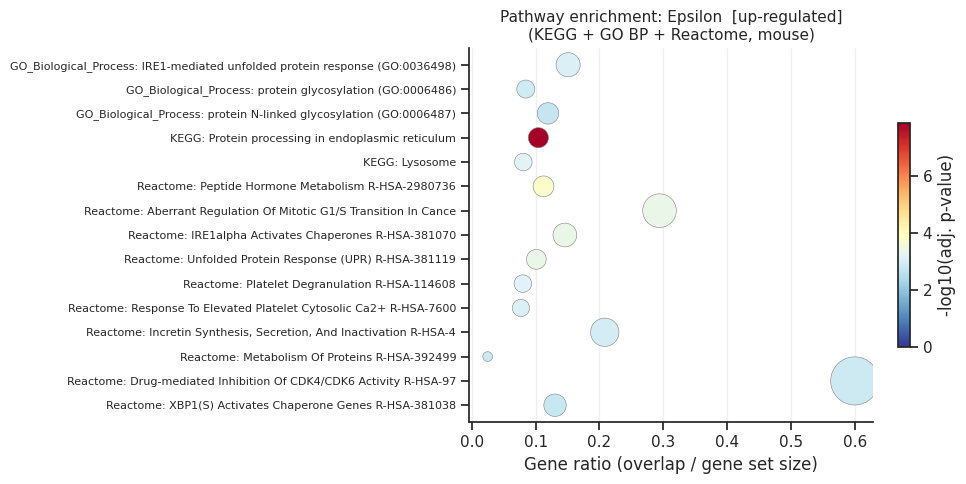

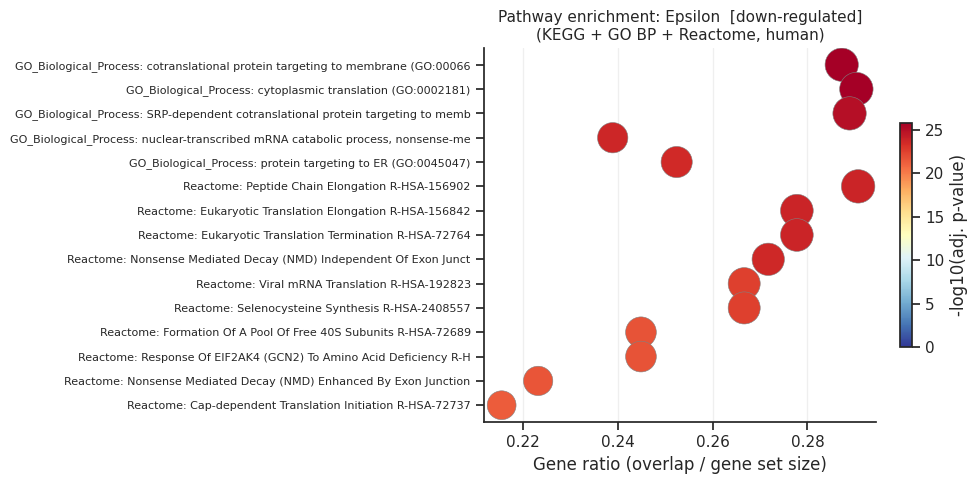

,fate,direction,Gene_set,Term,Overlap,Adjusted P-value
0,Alpha,up,KEGG_2019_Mouse,Protein processing in endoplasmic reticulum,17/163,3.014548e-06
1,Alpha,up,KEGG_2019_Mouse,Thyroid hormone synthesis,10/73,1.267707e-04
2,Alpha,up,KEGG_2019_Mouse,Lysosome,12/124,3.133244e-04
3,Alpha,down,GO_Biological_Process_2021,cotranslational protein targeting to membrane ...,24/94,1.627570e-17
4,Alpha,down,GO_Biological_Process_2021,cytoplasmic translation (GO:0002181),24/93,1.627570e-17
...,...,...,...,...,...,...
16,Epsilon,up,Reactome_2022,Peptide Hormone Metabolism R-HSA-2980736,10/89,1.607304e-04
17,Epsilon,up,Reactome_2022,Aberrant Regulation Of Mitotic G1/S Transition...,5/17,4.275598e-04
18,Epsilon,down,GO_Biological_Process_2021,cotranslational protein targeting to membrane ...,27/94,1.419635e-26
19,Epsilon,down,GO_Biological_Process_2021,cytoplasmic translation (GO:0002181),27/93,1.419635e-26


In [31]:
# Pathway enrichment per fate
# Note: requires gseapy and internet access for Enrichr API
# Results will be empty with synthetic data (too few significant DEGs)

try:
    enrichment = scorer.get_enrichment(
        deg_drivers,
        organism="mouse",     # "mouse" or "human"
        pval_threshold=0.05,
        logfc_threshold=0.25,
        plot=True,            # dot plots saved per fate
        n_top_pathways=15,
    )

    # Single compact summary: top 3 pathways per (fate, direction)
    enrich_df = _stack_enrichment(enrichment, n_per_group=3)
    if not enrich_df.empty:
        display(enrich_df[["fate", "direction", "Gene_set", "Term", "Overlap", "Adjusted P-value"]])
    else:
        print("(No enriched terms — typical with small / synthetic datasets.)")

except ImportError:
    print("gseapy not installed. Run: pip install gseapy")
except Exception as e:
    print(f"Enrichment skipped: {e}")
    print("(Expected with synthetic data — use real data for meaningful results.)")


In [32]:
# ── Custom gene sets ──────────────────────────────────────────────────────
# You can specify any Enrichr library:
# https://maayanlab.cloud/Enrichr/#libraries

custom_gene_sets = [
    'KEGG_2019_Mouse',
    'GO_Biological_Process_2021',
    'GO_Molecular_Function_2021',
    'Reactome_2022',
    'WikiPathway_2021_Mouse',
]

# enrichment = scorer.get_enrichment(
#     deg_drivers,
#     gene_sets=custom_gene_sets,
#     organism='mouse',
# )
print("Custom gene sets configured (commented out to avoid API call with synthetic data).")
print(f"Available sets: {custom_gene_sets}")


Custom gene sets configured (commented out to avoid API call with synthetic data).
Available sets: ['KEGG_2019_Mouse', 'GO_Biological_Process_2021', 'GO_Molecular_Function_2021', 'Reactome_2022', 'WikiPathway_2021_Mouse']


In [33]:
# Export enrichment tables to CSV
try:
    scCS.export_enrichment_tables(enrichment, output_dir="enrichment_results/")
    print("Tables saved to enrichment_results/")
except Exception as e:
    print(f"Export skipped: {e}")

Saved: enrichment_results/enrichment_Alpha_up.csv
Saved: enrichment_results/enrichment_Alpha_down.csv
Saved: enrichment_results/enrichment_Beta_up.csv
Saved: enrichment_results/enrichment_Beta_down.csv
Saved: enrichment_results/enrichment_Delta_up.csv
Saved: enrichment_results/enrichment_Epsilon_up.csv
Saved: enrichment_results/enrichment_Epsilon_down.csv
Tables saved to enrichment_results/


## 13. Expression trends along fate arms

`plot_expression_trends()` shows how gene expression changes along each fate arm,
ordered by a differentiation metric.

The `x_axis` parameter controls the ordering:
- `'affinity'` (default) — per-cell fate affinity score
- `'pseudotime'` — subset-local pseudotime
- `'radial_distance'` — distance from origin in the star embedding


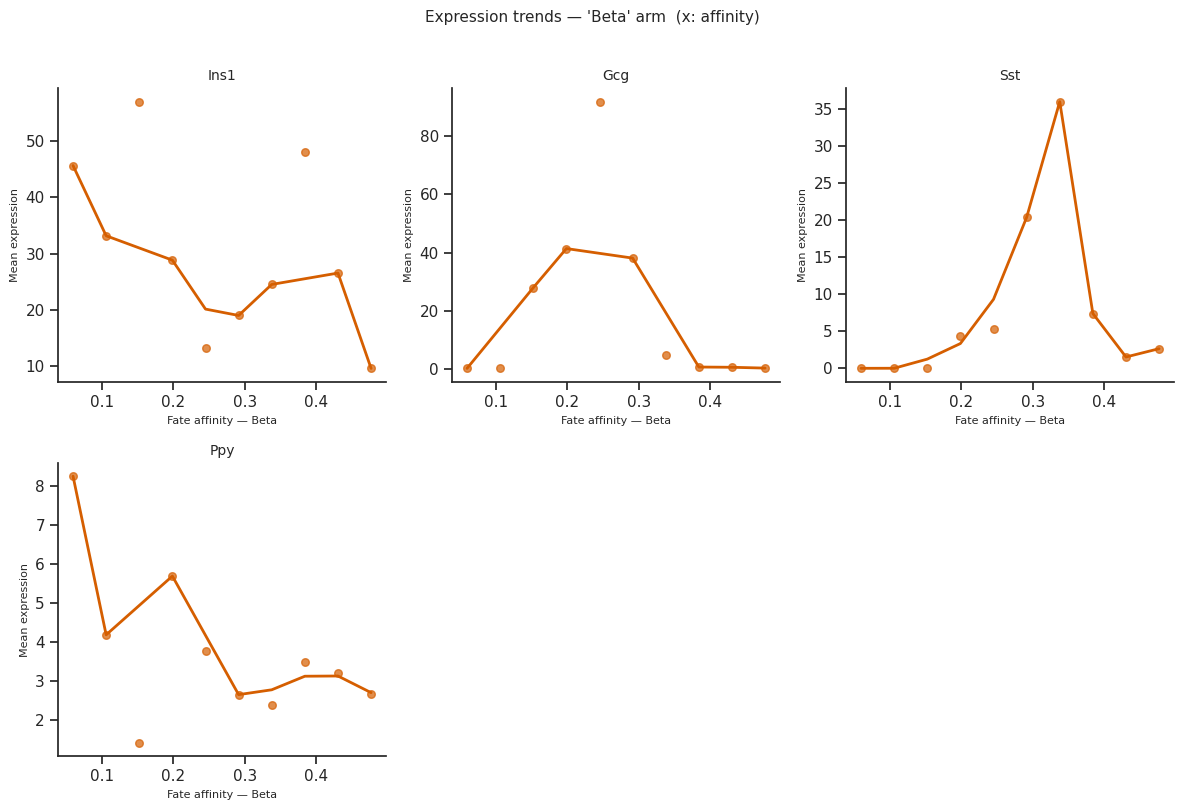

In [34]:
# Pick a few marker genes
genes_of_interest = ["Ins1", "Gcg", "Sst", "Ppy"]  # Beta, Alpha, Delta, Epsilon markers

# Expression trends ordered by fate affinity
# Signature: plot_expression_trends(adata_sub, result, genes, x_axis=...)
try:
    fig = scCS.plot_expression_trends(
        scorer.adata_sub,
        result,
        genes=genes_of_interest,
        x_axis="affinity",   # or 'pseudotime' or 'radial_distance'
        figsize=(12, 8),
    )
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Expression trends skipped: {e}")

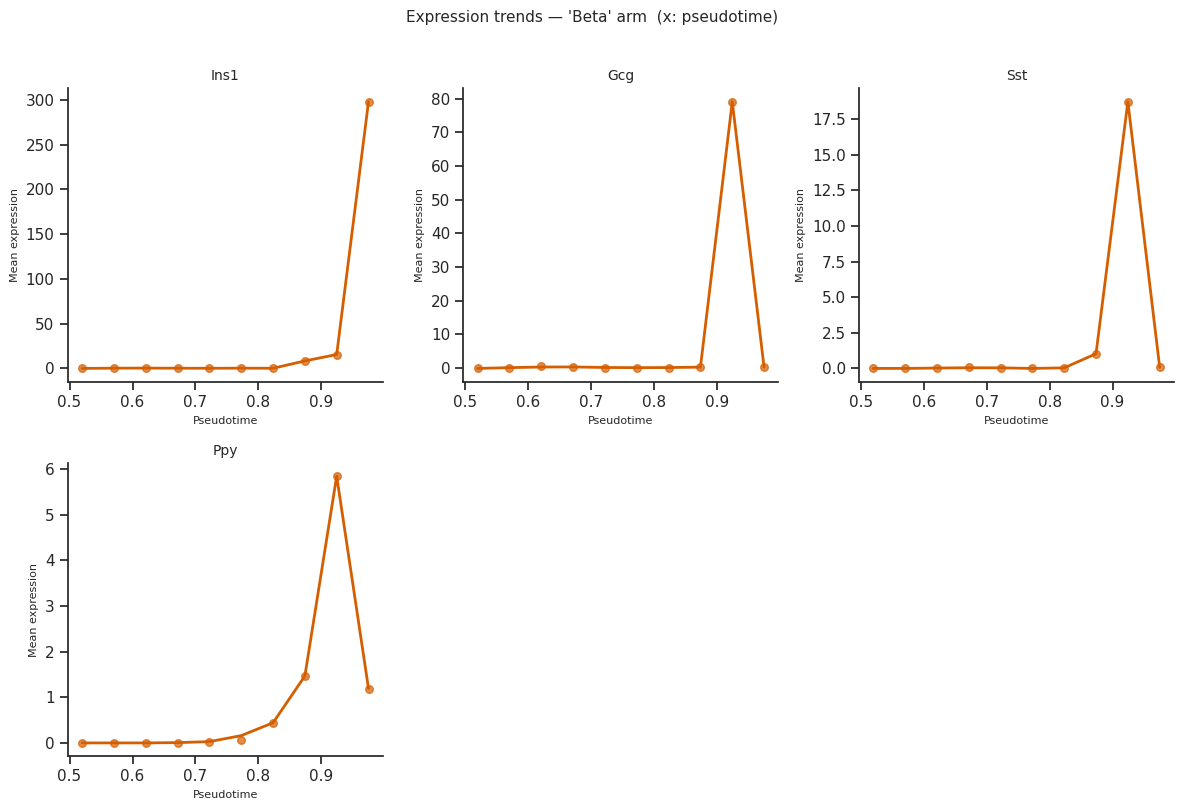

In [35]:
# Ordered by pseudotime
try:
    fig = scCS.plot_expression_trends(
        scorer.adata_sub,
        result,
        genes=genes_of_interest,
        x_axis="pseudotime",
        figsize=(12, 8),
    )
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Expression trends skipped: {e}")

In [36]:
obs_key = "clusters"   # <-- change to your obs column

color_map = dict(zip(
    adata.obs[obs_key].cat.categories,
    adata.uns[f"{obs_key}_colors"],
))
print(color_map)

{'Ductal': '#8fbc8f', 'Ngn3 low EP': '#f4a460', 'Ngn3 high EP': '#fdbf6f', 'Pre-endocrine': '#ff7f00', 'Beta': '#b2df8a', 'Alpha': '#1f78b4', 'Delta': '#6a3d9a', 'Epsilon': '#cab2d6'}


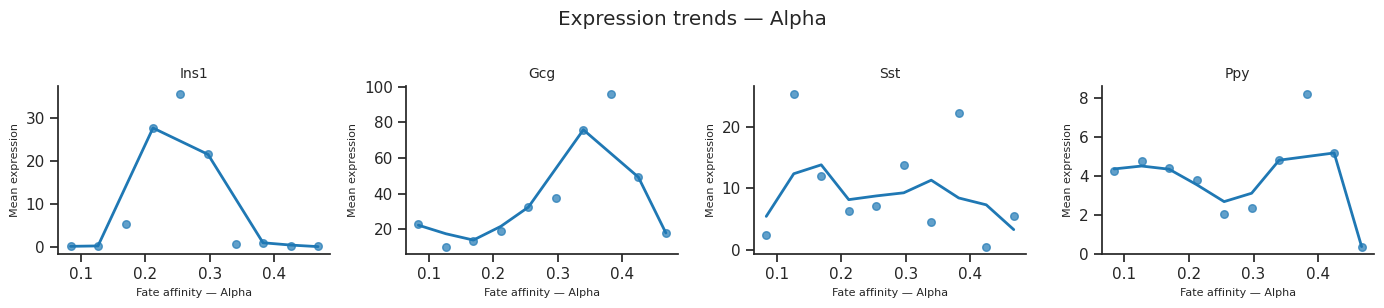

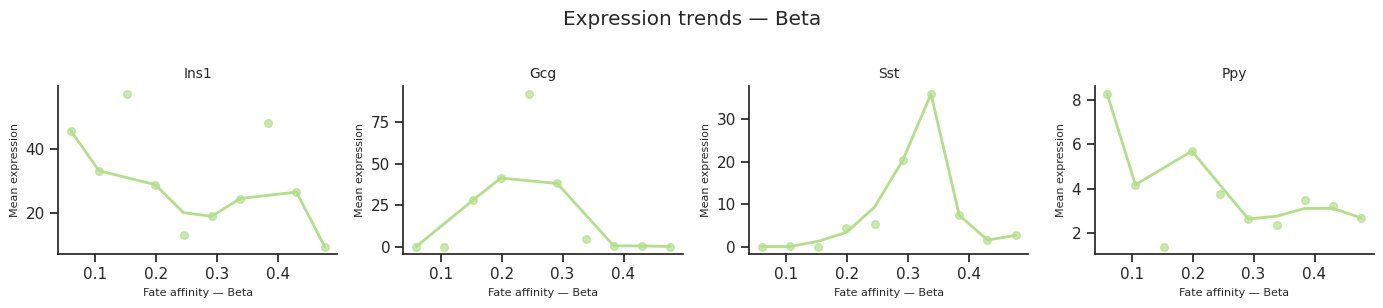

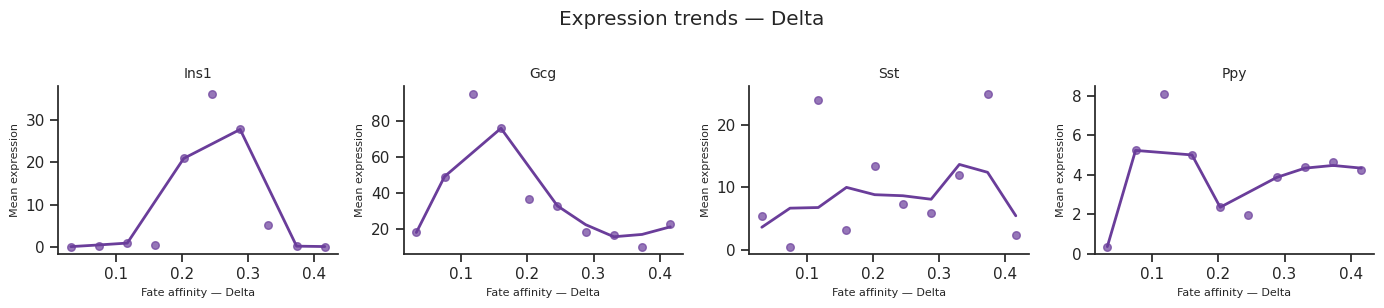

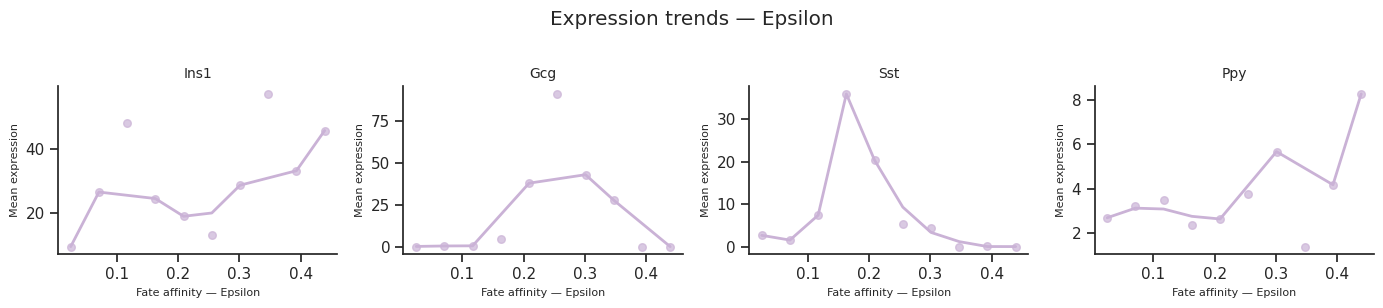

In [37]:
for fate_name in result.fate_names:
    fig = scCS.plot_expression_trends(
        adata, result,
        genes=genes_of_interest,
        fate=fate_name,
        color_map=color_map,
        ncols=4,
    )
    fig.suptitle(f"Expression trends — {fate_name}", y=1.02)
    fig.savefig(f"expression_trends_{fate_name}.svg", bbox_inches="tight")

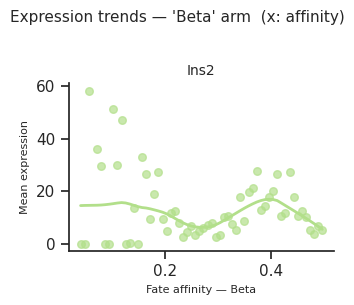

In [38]:
# CellRank-style: cells binned by per-cell CS for a chosen fate,
# mean expression per bin plotted with LOWESS smooth.
# Requires compute_cell_level=True (Cell 2 above).

genes_of_interest = ["Ins2"]   # <-- your genes

fig = scCS.plot_expression_trends(
    adata,
    result,
    genes=genes_of_interest,
    fate=result.dominant_fate,   # or e.g. fate="Activated"
    n_bins=60,                   # bins along CS axis
    layer=None,             # or None to use adata.X
    smooth=True,
    smooth_frac=0.4,             # LOWESS bandwidth (0–1)
    color_map=color_map,
    ncols=2,
)
plt.show()


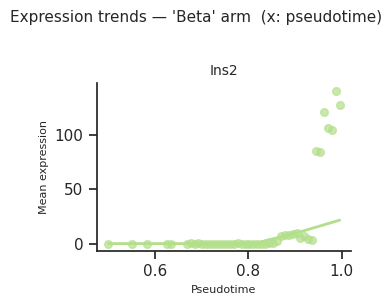

In [39]:
fig = scCS.plot_expression_trends(
    adata,
    result,
    genes=genes_of_interest,
    fate=result.dominant_fate,   # or e.g. fate="Activated"
    n_bins=60,                   # bins along CS axis
    layer=None,             # or None to use adata.X
    smooth=True,
    smooth_frac=0.4,             # LOWESS bandwidth (0–1)
    color_map=color_map,
    ncols=2, x_axis="pseudotime",
)
plt.show()

## Summary — scCS single-condition workflow

```python
import scCS

# 1. Create scorer
scorer = scCS.SingleScorer(
    adata,
    root="Ductal",
    branches=["Alpha", "Beta", "Delta", "Epsilon"],
    obs_key="clusters",
)

# 2. Build embedding (fix arm coverage)
scorer.build_embedding(ordering_metric="pseudotime")
scorer.refit_pseudotime(scale_01=True)

# 3. Fit & score
scorer.fit()
result = scorer.score(cell_level=True, k_nn=15, n_bootstrap=500)
print(result.summary())

# 4. Visualize
scorer.plot_star(result)
scorer.plot_rose(result)
scorer.plot_pairwise_cs(result)
scorer.plot_commitment_bar(result)

# 5. Transfer labels to full adata
scorer.transfer_labels(adata, result)

# 6. Driver genes & enrichment
vel_drivers = scorer.get_velocity_drivers()
deg_drivers = scorer.get_deg_drivers()
enrichment  = scorer.get_enrichment(deg_drivers, organism="Human")
```

For **multi-condition analysis**, see the companion notebooks